# EP1 Deep Learning — Fashion-MNIST

## Trabajo integrado: datos, MLP, experimentos, decisiones y evaluación final

Este es el notebook autónomo de entrega. Incluye el trabajo de Ignacio (datos, EDA y baseline), Lucas (funciones, hiperparámetros y capacidad) y César (optimización, regularización y evaluación final). No importa módulos, configuraciones, tablas ni figuras desde el repositorio: puede subirse y ejecutarse directamente en Google Colab.

**Protocolo:** todas las decisiones se toman con train/validation. El test oficial se usa una sola vez al final, después de congelar la configuración. No se debe ejecutar de nuevo la celda F1 en el mismo runtime.

## 0. Entorno reproducible

Colab normalmente ya incluye estas librerías. La celda instala solamente las que falten y fija la semilla de los experimentos.

In [1]:
import importlib.util
import subprocess
import sys

required = {'tensorflow': 'tensorflow', 'sklearn': 'scikit-learn', 'pandas': 'pandas', 'matplotlib': 'matplotlib'}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score, precision_recall_fscore_support, precision_score, recall_score)
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print('Python:', sys.version.split()[0])
print('TensorFlow:', tf.__version__)

Python: 3.12.13
TensorFlow: 2.21.0


## 1. Datos y preprocesamiento — Ignacio

Fashion-MNIST contiene 60.000 imágenes de entrenamiento y 10.000 de test, con 10 clases. Las imágenes son de `28×28` píxeles en escala de grises. Se reserva un 10% del conjunto de entrenamiento para validation mediante una partición estratificada; así cada clase conserva 5.400 ejemplos en train y 600 en validation.

Las imágenes se convierten a `float32` y se normalizan desde `[0, 255]` a `[0, 1]`. Las etiquetas se codifican one-hot, consistente con la salida Softmax y categorical crossentropy.

Train: (54000, 28, 28) (54000, 10)
Validation: (6000, 28, 28) (6000, 10)
Test (sellado hasta F1): (10000, 28, 28) (10000, 10)
Rango normalizado: float32 0.0 1.0


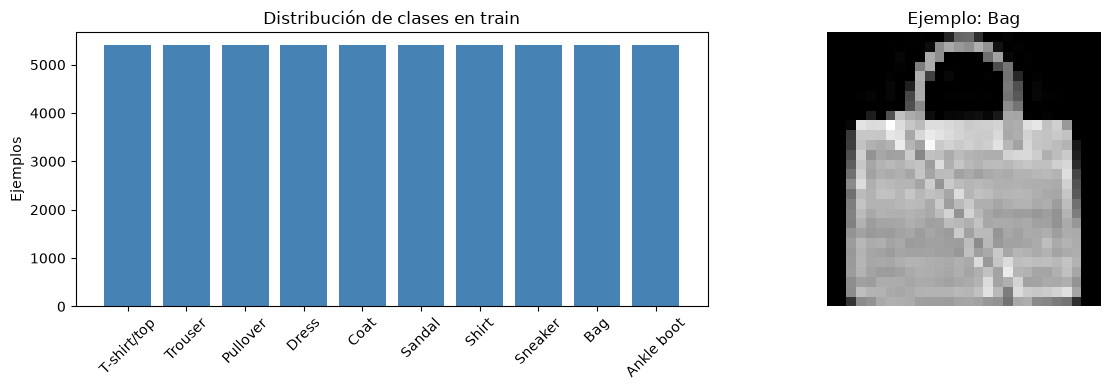

In [2]:
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
(X_pool_raw, y_pool), (X_test_raw, y_test_raw) = tf.keras.datasets.fashion_mnist.load_data()
train_index, validation_index = train_test_split(
    np.arange(y_pool.size), test_size=0.1, random_state=SEED, stratify=y_pool
)
X_train = X_pool_raw[train_index].astype('float32') / 255.0
X_val = X_pool_raw[validation_index].astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0
y_train_ids, y_val_ids = y_pool[train_index], y_pool[validation_index]
y_train = tf.keras.utils.to_categorical(y_train_ids, 10)
y_val = tf.keras.utils.to_categorical(y_val_ids, 10)
y_test = tf.keras.utils.to_categorical(y_test_raw, 10)

print('Train:', X_train.shape, y_train.shape)
print('Validation:', X_val.shape, y_val.shape)
print('Test (sellado hasta F1):', X_test.shape, y_test.shape)
print('Rango normalizado:', X_train.dtype, float(X_train.min()), float(X_train.max()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(CLASS_NAMES, np.bincount(y_train_ids), color='steelblue')
axes[0].set(title='Distribución de clases en train', ylabel='Ejemplos')
axes[0].tick_params(axis='x', rotation=45)
for ax, (image, label) in zip(axes[1].flat if hasattr(axes[1], 'flat') else [axes[1]], [(X_train[0], y_train_ids[0])]):
    ax.imshow(image, cmap='gray'); ax.set_title(f'Ejemplo: {CLASS_NAMES[label]}'); ax.axis('off')
plt.tight_layout(); plt.show()

## 2. Infraestructura experimental común

La función siguiente implementa una MLP configurable y un ejecutor de **validation**. Cada experimento conserva la misma semilla y cambia solamente la variable declarada. El ejecutor no llama a `X_test` ni a `y_test`.

In [5]:
def set_seed(seed):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)

def build_mlp(config):
    regularizer = tf.keras.regularizers.l2(config['l2']) if config['l2'] else None
    inputs = tf.keras.Input(shape=(28, 28))
    x = tf.keras.layers.Flatten()(inputs)
    for units in config['layers']:
        activation = None if config['batch_norm'] else config['hidden_activation']
        x = tf.keras.layers.Dense(units, activation=activation, kernel_regularizer=regularizer)(x)
        if config['batch_norm']:
            x = tf.keras.layers.BatchNormalization()(x)
            x = tf.keras.layers.Activation(config['hidden_activation'])(x)
        if config['dropout']:
            x = tf.keras.layers.Dropout(config['dropout'])(x)
    outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

def make_optimizer(name, learning_rate):
    optimizers = {'sgd': tf.keras.optimizers.SGD, 'adam': tf.keras.optimizers.Adam, 'rmsprop': tf.keras.optimizers.RMSprop}
    return optimizers[name](learning_rate=learning_rate)

def metric_row(identifier, config, history, actual, predicted, parameters):
    return {
        'ID': identifier, 'optimizer': config['optimizer'], 'lr': config['lr'], 'batch': config['batch'],
        'layers': str(config['layers']), 'dropout': config['dropout'], 'batch_norm': config['batch_norm'], 'l2': config['l2'],
        'accuracy': accuracy_score(actual, predicted),
        'precision_macro': precision_score(actual, predicted, average='macro', zero_division=0),
        'recall_macro': recall_score(actual, predicted, average='macro', zero_division=0),
        'f1_macro': f1_score(actual, predicted, average='macro', zero_division=0),
        'precision_weighted': precision_score(actual, predicted, average='weighted', zero_division=0),
        'recall_weighted': recall_score(actual, predicted, average='weighted', zero_division=0),
        'f1_weighted': f1_score(actual, predicted, average='weighted', zero_division=0),
        'best_val_accuracy_epoch': int(np.argmax(history['val_accuracy']) + 1),
        'best_val_loss_epoch': int(np.argmin(history['val_loss']) + 1),
        'gap_accuracy': history['accuracy'][-1] - history['val_accuracy'][-1],
        'gap_loss': history['val_loss'][-1] - history['loss'][-1],
        'parameters': parameters
    }

def run_validation(identifier, config):
    set_seed(config['seed'])
    model = build_mlp(config)
    model.compile(optimizer=make_optimizer(config['optimizer'], config['lr']), loss=config['loss'], metrics=['accuracy'])
    fit = model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=config['batch'], epochs=config['epochs'], verbose=0)
    probabilities = model.predict(X_val, verbose=0)
    return {'config': config, 'history': fit.history, 'row': metric_row(identifier, config, fit.history, y_val_ids, probabilities.argmax(axis=1), model.count_params())}

def show_results(records, identifiers, columns=None):
    frame = pd.DataFrame([records[i]['row'] for i in identifiers])
    columns = columns or ['ID', 'accuracy', 'f1_macro', 'best_val_accuracy_epoch', 'best_val_loss_epoch', 'gap_accuracy', 'gap_loss']
    display(frame[columns].style.format({column: '{:.4f}' for column in ['accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'] if column in columns}))

def plot_curves(records, identifiers, field, title):
    fig, axis = plt.subplots(figsize=(8, 4))
    for identifier in identifiers:
        axis.plot(records[identifier]['history'][field], label=identifier)
    axis.set(title=title, xlabel='Época', ylabel=field.replace('_', ' '))
    axis.legend(fontsize=8); axis.grid(alpha=.25); plt.show()

BASE = {'seed': SEED, 'layers': [256, 128], 'hidden_activation': 'relu', 'loss': 'categorical_crossentropy', 'optimizer': 'sgd', 'lr': 0.01, 'batch': 128, 'epochs': 20, 'dropout': 0.0, 'batch_norm': False, 'l2': 0.0}
records = {}

## 3. Baseline, activación y función de pérdida — Ignacio

E0 establece el control: MLP `[256, 128]`, ReLU, Softmax y categorical crossentropy. E1 cambia exclusivamente la activación oculta; E2 cambia exclusivamente la pérdida. La comparación permite defender ReLU y categorical crossentropy para este problema multiclase.

,ID,accuracy,f1_macro,best_val_accuracy_epoch,best_val_loss_epoch,gap_accuracy,gap_loss
0,E0,0.8722,0.8726,20,20,-0.0036,-0.0084
1,E1_tanh,0.8643,0.8647,20,20,0.0014,-0.0036
2,E1_sigmoid,0.7535,0.7490,20,20,-0.0079,-0.0181
3,E2_mse,0.7370,0.7168,20,20,-0.0051,-0.0006


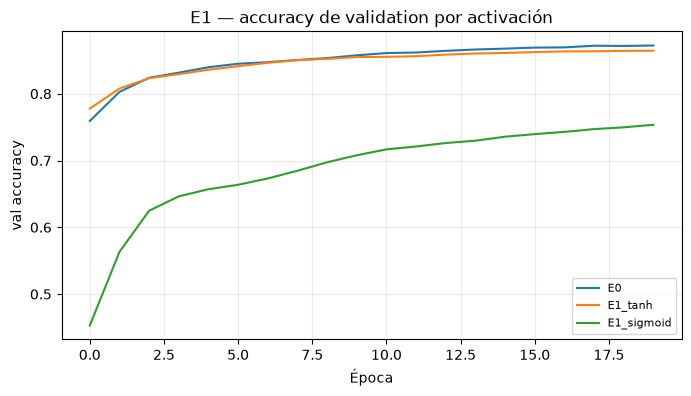

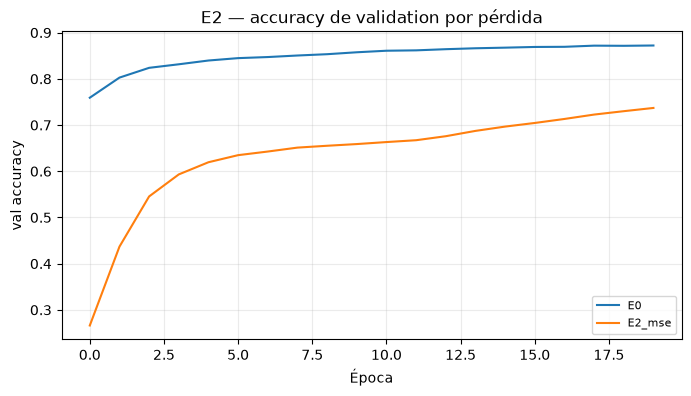

Decisión: ReLU + Softmax + categorical crossentropy se conserva como control.


In [ ]:
records['E0'] = run_validation('E0', BASE)
for identifier, changes in {
    'E1_tanh': {'hidden_activation': 'tanh'},
    'E1_sigmoid': {'hidden_activation': 'sigmoid'},
    'E2_mse': {'loss': 'mean_squared_error'},
}.items():
    config = BASE | changes
    records[identifier] = run_validation(identifier, config)

show_results(records, ['E0', 'E1_tanh', 'E1_sigmoid', 'E2_mse'])
plot_curves(records, ['E0', 'E1_tanh', 'E1_sigmoid'], 'val_accuracy', 'E1 — accuracy de validation por activación')
plot_curves(records, ['E0', 'E2_mse'], 'val_accuracy', 'E2 — accuracy de validation por pérdida')
print('Decisión: ReLU + Softmax + categorical crossentropy se conserva como control.')

## 4. Learning rate, batch size y capacidad — Lucas

E3 compara learning rates; E4 compara batch sizes usando el learning rate seleccionado; E5 compara capacidad. Se reutilizan los controles idénticos ya ejecutados para no repetir entrenamiento sin aportar evidencia nueva.

,ID,lr,accuracy,f1_macro,gap_accuracy,gap_loss
0,E3_lr_0_001,0.001000,0.8053,0.8034,-0.0065,-0.0113
1,E0,0.010000,0.8722,0.8726,-0.0036,-0.0084
2,E3_lr_0_1,0.100000,0.8937,0.8939,0.0302,0.0881


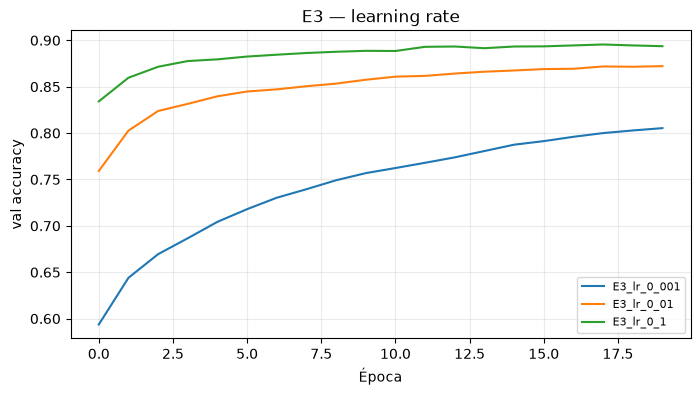

,ID,batch,accuracy,f1_macro,gap_accuracy,gap_loss
0,E4_batch_32,32,0.8837,0.8844,0.0585,0.2018
1,E3_lr_0_1,128,0.8937,0.8939,0.0302,0.0881
2,E4_batch_512,512,0.8750,0.8776,0.0095,0.0305


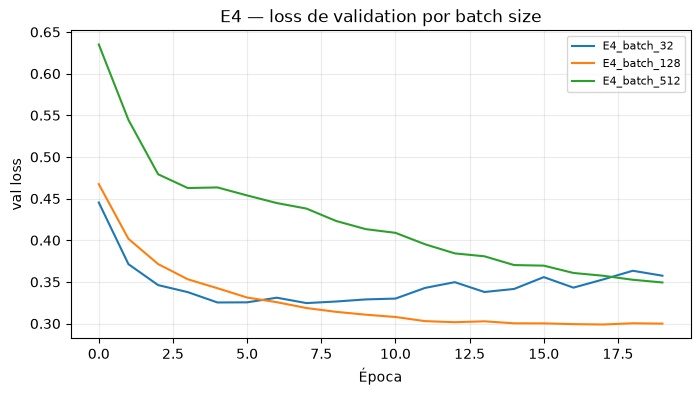

,ID,layers,parameters,accuracy,f1_macro,gap_accuracy,gap_loss
0,E5_capacity_64,[64],50890,0.8878,0.8885,0.0092,0.0254
1,E3_lr_0_1,"[256, 128]",235146,0.8937,0.8939,0.0302,0.0881
2,E5_capacity_512_256_128,"[512, 256, 128]",567434,0.8963,0.8963,0.0313,0.1009


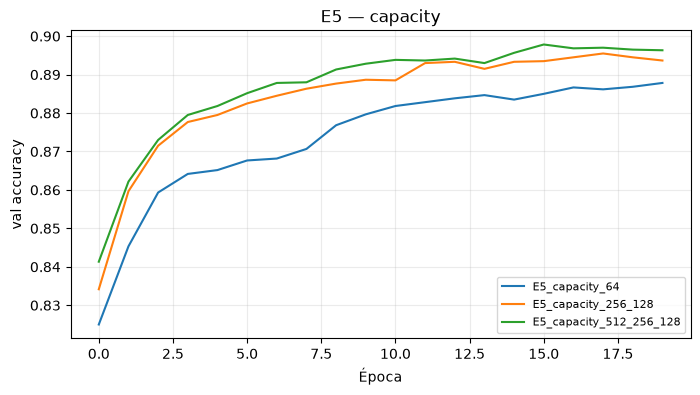

Decisión: LR 0.1, batch 128 y [256, 128] equilibran desempeño, costo y generalización.


In [7]:
records['E3_lr_0_001'] = run_validation('E3_lr_0_001', BASE | {'lr': 0.001})
records['E3_lr_0_01'] = records['E0']
records['E3_lr_0_1'] = run_validation('E3_lr_0_1', BASE | {'lr': 0.1})
show_results(records, ['E3_lr_0_001', 'E3_lr_0_01', 'E3_lr_0_1'], ['ID', 'lr', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E3_lr_0_001', 'E3_lr_0_01', 'E3_lr_0_1'], 'val_accuracy', 'E3 — learning rate')

CONTROL = BASE | {'lr': 0.1}
records['E4_batch_32'] = run_validation('E4_batch_32', CONTROL | {'batch': 32})
records['E4_batch_128'] = records['E3_lr_0_1']
records['E4_batch_512'] = run_validation('E4_batch_512', CONTROL | {'batch': 512})
show_results(records, ['E4_batch_32', 'E4_batch_128', 'E4_batch_512'], ['ID', 'batch', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E4_batch_32', 'E4_batch_128', 'E4_batch_512'], 'val_loss', 'E4 — loss de validation por batch size')

records['E5_capacity_64'] = run_validation('E5_capacity_64', CONTROL | {'layers': [64]})
records['E5_capacity_256_128'] = records['E3_lr_0_1']
records['E5_capacity_512_256_128'] = run_validation('E5_capacity_512_256_128', CONTROL | {'layers': [512, 256, 128]})
show_results(records, ['E5_capacity_64', 'E5_capacity_256_128', 'E5_capacity_512_256_128'], ['ID', 'layers', 'parameters', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E5_capacity_64', 'E5_capacity_256_128', 'E5_capacity_512_256_128'], 'val_accuracy', 'E5 — capacity')
print('Decisión: LR 0.1, batch 128 y [256, 128] equilibran desempeño, costo y generalización.')

## 5. Optimizadores y retuning separado — César

E6 cambia exclusivamente el optimizador bajo un learning rate común. Si un optimizador necesita otra escala, E6b cambia exclusivamente su learning rate para no atribuir a una sola variable dos efectos distintos.

,ID,optimizer,lr,accuracy,f1_macro,gap_accuracy,gap_loss
0,E3_lr_0_1,sgd,0.100000,0.8937,0.8939,0.0302,0.0881
1,E6_optimizer_rmsprop,rmsprop,0.100000,0.1000,0.0182,-0.0001,0.0058
2,E6_optimizer_adam,adam,0.100000,0.3710,0.3056,0.0215,0.0376


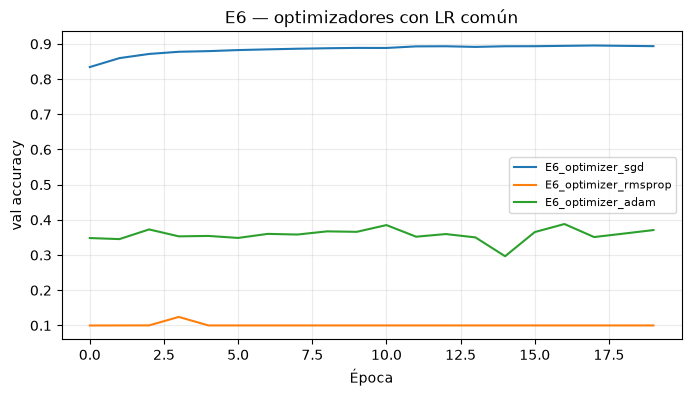

,ID,optimizer,lr,accuracy,f1_macro,gap_accuracy,gap_loss
0,E3_lr_0_1,sgd,0.100000,0.8937,0.8939,0.0302,0.0881
1,E6b_adam_lr_0_001,adam,0.001000,0.9022,0.9022,0.0404,0.1659
2,E6b_rmsprop_lr_0_001,rmsprop,0.001000,0.8913,0.8917,0.0496,0.2191


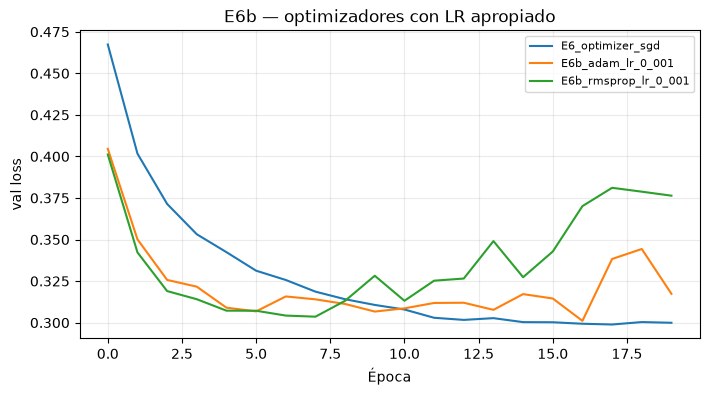

Decisión provisional: continuar con SGD LR 0.1; los adaptativos requieren una escala distinta, pero no lo superan bajo este presupuesto.


In [8]:
records['E6_optimizer_sgd'] = records['E3_lr_0_1']
records['E6_optimizer_rmsprop'] = run_validation('E6_optimizer_rmsprop', CONTROL | {'optimizer': 'rmsprop'})
records['E6_optimizer_adam'] = run_validation('E6_optimizer_adam', CONTROL | {'optimizer': 'adam'})
show_results(records, ['E6_optimizer_sgd', 'E6_optimizer_rmsprop', 'E6_optimizer_adam'], ['ID', 'optimizer', 'lr', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E6_optimizer_sgd', 'E6_optimizer_rmsprop', 'E6_optimizer_adam'], 'val_accuracy', 'E6 — optimizadores con LR común')

records['E6b_adam_lr_0_001'] = run_validation('E6b_adam_lr_0_001', CONTROL | {'optimizer': 'adam', 'lr': 0.001})
records['E6b_rmsprop_lr_0_001'] = run_validation('E6b_rmsprop_lr_0_001', CONTROL | {'optimizer': 'rmsprop', 'lr': 0.001})
show_results(records, ['E6_optimizer_sgd', 'E6b_adam_lr_0_001', 'E6b_rmsprop_lr_0_001'], ['ID', 'optimizer', 'lr', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E6_optimizer_sgd', 'E6b_adam_lr_0_001', 'E6b_rmsprop_lr_0_001'], 'val_loss', 'E6b — optimizadores con LR apropiado')
print('Decisión provisional: continuar con SGD LR 0.1; los adaptativos requieren una escala distinta, pero no lo superan bajo este presupuesto.')

## 6. Regularización y estabilidad — César

E7, E8 y E9 aíslan Dropout, Batch Normalization y L2. Se comparan Accuracy, F1 Macro, curvas y gaps train-validation. La capa Batch Normalization, cuando se activa, se ubica entre Dense lineal y ReLU.

,ID,dropout,accuracy,f1_macro,gap_accuracy,gap_loss
0,E3_lr_0_1,0.000000,0.8937,0.8939,0.0302,0.0881
1,E7_dropout_0_2,0.200000,0.8953,0.8965,0.0049,0.0147


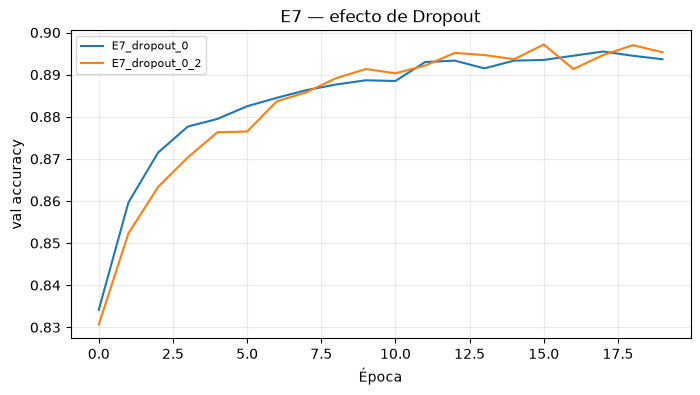

,ID,batch_norm,parameters,accuracy,f1_macro,gap_accuracy,gap_loss
0,E7_dropout_0_2,False,235146,0.8953,0.8965,0.0049,0.0147
1,E8_batch_norm_on,True,236682,0.8938,0.8945,0.0282,0.0874


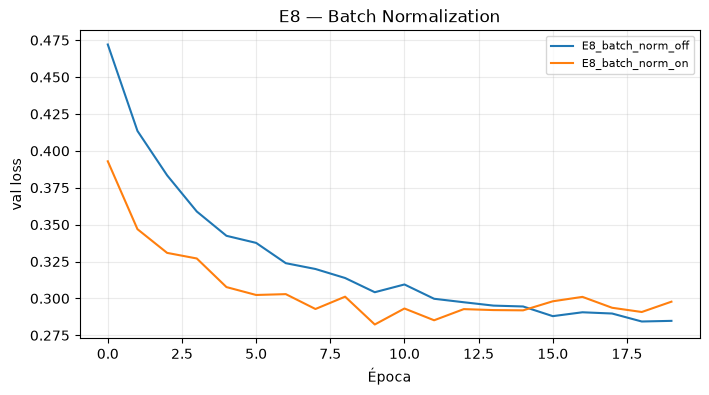

,ID,l2,accuracy,f1_macro,gap_accuracy,gap_loss
0,E7_dropout_0_2,0.000000,0.8953,0.8965,0.0049,0.0147
1,E9_l2_1e-4,0.000100,0.8935,0.8947,0.0050,0.0127


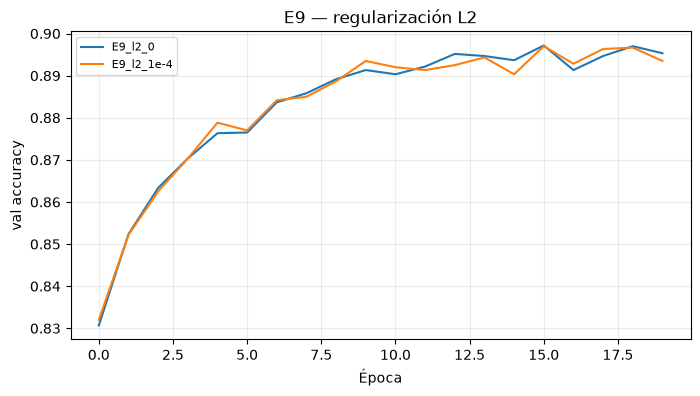

Decisión: usar Dropout 0.2; mantener BatchNorm y L2 desactivados en esta configuración.


In [9]:
records['E7_dropout_0'] = records['E6_optimizer_sgd']
records['E7_dropout_0_2'] = run_validation('E7_dropout_0_2', CONTROL | {'dropout': 0.2})
show_results(records, ['E7_dropout_0', 'E7_dropout_0_2'], ['ID', 'dropout', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E7_dropout_0', 'E7_dropout_0_2'], 'val_accuracy', 'E7 — efecto de Dropout')

DROPOUT_CONTROL = CONTROL | {'dropout': 0.2}
records['E8_batch_norm_off'] = records['E7_dropout_0_2']
records['E8_batch_norm_on'] = run_validation('E8_batch_norm_on', DROPOUT_CONTROL | {'batch_norm': True})
show_results(records, ['E8_batch_norm_off', 'E8_batch_norm_on'], ['ID', 'batch_norm', 'parameters', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E8_batch_norm_off', 'E8_batch_norm_on'], 'val_loss', 'E8 — Batch Normalization')

records['E9_l2_0'] = records['E8_batch_norm_off']
records['E9_l2_1e-4'] = run_validation('E9_l2_1e-4', DROPOUT_CONTROL | {'l2': 1e-4})
show_results(records, ['E9_l2_0', 'E9_l2_1e-4'], ['ID', 'l2', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])
plot_curves(records, ['E9_l2_0', 'E9_l2_1e-4'], 'val_accuracy', 'E9 — regularización L2')
print('Decisión: usar Dropout 0.2; mantener BatchNorm y L2 desactivados en esta configuración.')

## 7. Repetición y congelamiento F0

Las diferencias marginales de L2 se repiten con una segunda seed antes de fijar el modelo. Early Stopping no se activa: las curvas del control alcanzan su mejor validation accuracy y loss al final de las 20 épocas, por lo que no existe una oportunidad material para introducir un callback adicional.

In [10]:
records['R_e9_l2_0_seed_7'] = run_validation('R_e9_l2_0_seed_7', DROPOUT_CONTROL | {'seed': 7})
records['R_e9_l2_1e-4_seed_7'] = run_validation('R_e9_l2_1e-4_seed_7', DROPOUT_CONTROL | {'seed': 7, 'l2': 1e-4})
show_results(records, ['E9_l2_0', 'E9_l2_1e-4', 'R_e9_l2_0_seed_7', 'R_e9_l2_1e-4_seed_7'], ['ID', 'l2', 'accuracy', 'f1_macro', 'gap_accuracy', 'gap_loss'])

FROZEN = DROPOUT_CONTROL | {'seed': SEED, 'batch_norm': False, 'l2': 0.0}
assert FROZEN == records['E7_dropout_0_2']['config']
print('F0 congelada antes de test:', FROZEN)
print('La evaluación F1 de la siguiente celda será la única predicción sobre X_test.')

,ID,l2,accuracy,f1_macro,gap_accuracy,gap_loss
0,E7_dropout_0_2,0.000000,0.8953,0.8965,0.0049,0.0147
1,E9_l2_1e-4,0.000100,0.8935,0.8947,0.0050,0.0127
2,R_e9_l2_0_seed_7,0.000000,0.8968,0.8967,0.0017,0.0141
3,R_e9_l2_1e-4_seed_7,0.000100,0.9013,0.9014,-0.0035,0.0086


F0 congelada antes de test: {'seed': 42, 'layers': [256, 128], 'hidden_activation': 'relu', 'loss': 'categorical_crossentropy', 'optimizer': 'sgd', 'lr': 0.1, 'batch': 128, 'epochs': 20, 'dropout': 0.2, 'batch_norm': False, 'l2': 0.0}
La evaluación F1 de la siguiente celda será la única predicción sobre X_test.


## 8. F1 — evaluación final única sobre test

Esta es la única celda que usa test. Entrena exactamente la configuración congelada y produce Accuracy, Precision, Recall, F1 macro/ponderado, métricas por clase, matriz de confusión y ejemplos de errores. Una guardia impide repetir F1 en el mismo runtime.

,Test
Accuracy,0.8801
Precision macro,0.8835
Recall macro,0.8801
F1 macro,0.8811
Precision ponderada,0.8835
Recall ponderado,0.8801
F1 ponderado,0.8811


,Clase,Precision,Recall,F1,Soporte
0,T-shirt/top,0.8686,0.7800,0.8219,1000
1,Trouser,0.9938,0.9620,0.9776,1000
2,Pullover,0.8050,0.7720,0.7882,1000
3,Dress,0.8604,0.9120,0.8854,1000
4,Coat,0.8024,0.8040,0.8032,1000
5,Sandal,0.9775,0.9560,0.9666,1000
6,Shirt,0.6537,0.7380,0.6933,1000
7,Sneaker,0.9237,0.9680,0.9453,1000
8,Bag,0.9816,0.9610,0.9712,1000
9,Ankle boot,0.9683,0.9480,0.9581,1000


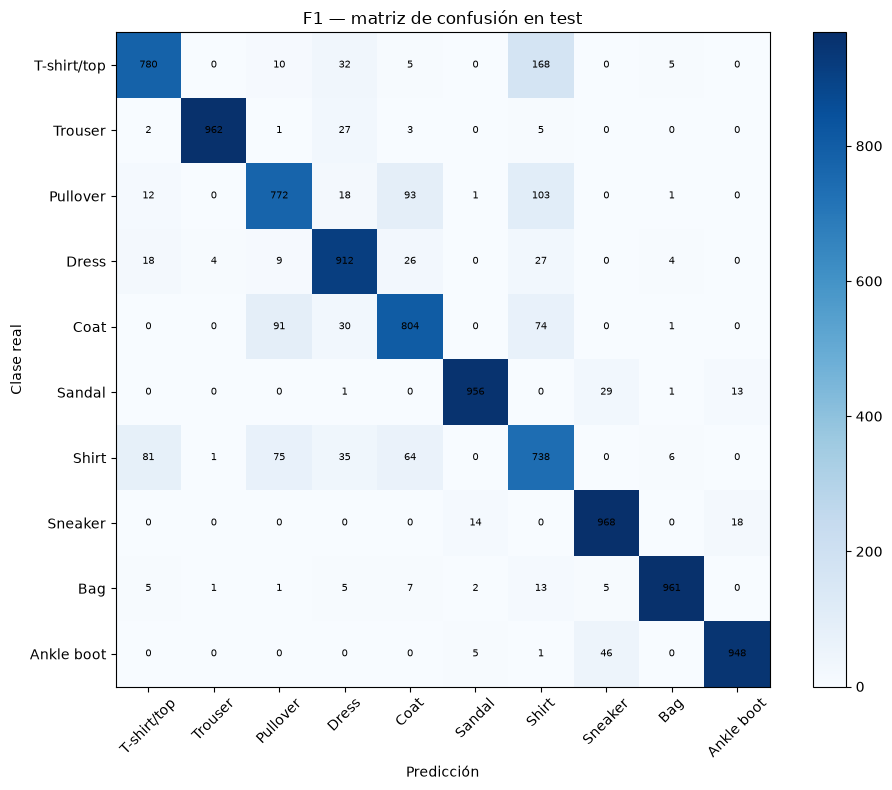

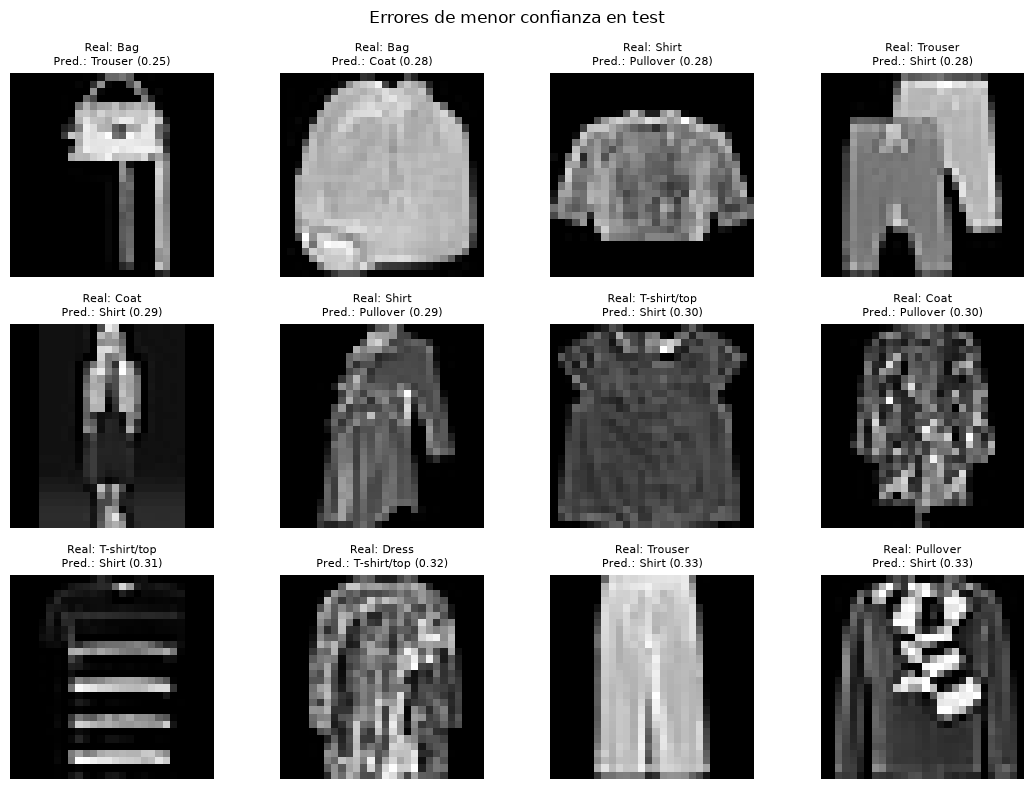

In [11]:
if '_F1_TEST_ALREADY_EVALUATED' in globals():
    raise RuntimeError('F1 ya fue ejecutada en este runtime. Reinicie el runtime antes de una nueva ejecución completa.')
_F1_TEST_ALREADY_EVALUATED = True

set_seed(FROZEN['seed'])
final_model = build_mlp(FROZEN)
final_model.compile(optimizer=make_optimizer(FROZEN['optimizer'], FROZEN['lr']), loss=FROZEN['loss'], metrics=['accuracy'])
final_model.fit(X_train, y_train, validation_data=(X_val, y_val), batch_size=FROZEN['batch'], epochs=FROZEN['epochs'], verbose=0)
test_probabilities = final_model.predict(X_test, verbose=0)
test_predicted = test_probabilities.argmax(axis=1)

final_metrics = pd.DataFrame([{
    'Accuracy': accuracy_score(y_test_raw, test_predicted),
    'Precision macro': precision_score(y_test_raw, test_predicted, average='macro', zero_division=0),
    'Recall macro': recall_score(y_test_raw, test_predicted, average='macro', zero_division=0),
    'F1 macro': f1_score(y_test_raw, test_predicted, average='macro', zero_division=0),
    'Precision ponderada': precision_score(y_test_raw, test_predicted, average='weighted', zero_division=0),
    'Recall ponderado': recall_score(y_test_raw, test_predicted, average='weighted', zero_division=0),
    'F1 ponderado': f1_score(y_test_raw, test_predicted, average='weighted', zero_division=0),
}]).T.rename(columns={0: 'Test'})
display(final_metrics.style.format({'Test': '{:.4f}'}))

precision, recall, f1, support = precision_recall_fscore_support(y_test_raw, test_predicted, labels=range(10), zero_division=0)
per_class = pd.DataFrame({'Clase': CLASS_NAMES, 'Precision': precision, 'Recall': recall, 'F1': f1, 'Soporte': support})
display(per_class.style.format({'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'}))

matrix = confusion_matrix(y_test_raw, test_predicted, labels=range(10))
fig, axis = plt.subplots(figsize=(10, 8))
image = axis.imshow(matrix, cmap='Blues'); fig.colorbar(image, ax=axis)
axis.set(xticks=range(10), yticks=range(10), xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, xlabel='Predicción', ylabel='Clase real', title='F1 — matriz de confusión en test')
axis.tick_params(axis='x', rotation=45)
for row in range(10):
    for column in range(10):
        axis.text(column, row, str(matrix[row, column]), ha='center', va='center', fontsize=7)
plt.tight_layout(); plt.show()

errors = np.flatnonzero(y_test_raw != test_predicted)
selected = errors[np.argsort(test_probabilities[errors, test_predicted[errors]])[:12]]
fig, axes = plt.subplots(3, 4, figsize=(11, 8))
for axis, index in zip(axes.flat, selected):
    axis.imshow(X_test[index], cmap='gray')
    confidence = test_probabilities[index, test_predicted[index]]
    axis.set_title(f'Real: {CLASS_NAMES[y_test_raw[index]]}\nPred.: {CLASS_NAMES[test_predicted[index]]} ({confidence:.2f})', fontsize=8)
    axis.axis('off')
plt.suptitle('Errores de menor confianza en test'); plt.tight_layout(); plt.show()

## 9. Conclusiones integradas

- La normalización y la partición estratificada entregan un contrato de datos reproducible y evitan usar test durante el ajuste.
- ReLU, Softmax y categorical crossentropy fueron apropiadas para la clasificación multiclase; learning rate `0,1`, batch `128` y arquitectura `[256, 128]` entregaron un equilibrio adecuado.
- En el presupuesto estudiado, SGD fue el control más consistente tras retunear separadamente a Adam y RMSProp.
- Dropout `0,2` fue la mejora de generalización seleccionada. Batch Normalization y L2 no superaron ese control, resultado que es contextual a este experimento.
- F1 se interpreta como evaluación final: no se ajusta el modelo después de observar test. La clase más difícil suele ser `Shirt`, con confusiones razonables entre prendas superiores visualmente similares.

Para guardar la evidencia de Colab: `File → Download → Download .ipynb` después de ejecutar todas las celdas en un runtime nuevo.